# LR 10

## Упражнения

Мы рассмотрим набор данных [Libras](https://www.timeseriesclassification.com/description.php?Dataset=Libras). Набор данных содержит 15 классов по 24 экземпляра в каждом. Каждый класс ссылается на тип движения руки в LIBRAS (португальское название «LÍngua BRAsileira de Sinais», официальный бразильский язык сигналов).

In [ ]:
Xtr, Ytr, Xte, Yte = DataLoader().get_data('Libras')

Loaded Libras dataset.
Number of classes: 15
Data shapes:
  Xtr: (180, 45, 2)
  Ytr: (180, 1)
  Xte: (180, 45, 2)
  Yte: (180, 1)


### Упражнение 1

1. Вычислите матрицу расстояний DTW.
2. Получите из нее матрицу сходства.
3. Постройте две матрицы. Прокомментируйте структуру, которую вы видите (не забудьте отсортировать элементы по классам).
4. Выполните классификацию с помощью классификаторов SVC и $k$-NN и сообщите:
- время обучения и тестирования,
- точность и оценку F1 на тестовом наборе.
5. Выполните иерархическую кластеризацию с помощью алгоритма Linkage Ward.
6. Постройте дендрограмму и проверьте ее, чтобы выбрать оптимальный порог для генерации кластерного раздела. Сообщите NMI для найденного вами раздела.
7. Выполните снижение размерности с помощью KernelPCA. Постройте результаты на двумерном графике.

### Упражнение 2

1. Добавьте 40% пропущенных значений к обучающим и тестовым данным.
2. Вычислите ядро ​​TCK.
3. Вычислите матрицу различий из ядра (попробуйте сделать дополнительное к тому, что вы сделали для получения сходства из DTW).

Повторите пункты 4–7 из предыдущего упражнения.

### Упражнение 3

1. Вычислите RC-вложения.
2. Получите матрицу сходства и различия из представлений MTS.

Повторите пункты 4–7 из предыдущих упражнений.

# _________________________________________________________________________________________

Imports

In [1]:
!pip install -U -qq reservoir_computing tsa_course tck dtaidistance

In [3]:
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets, svm
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, f1_score, v_measure_score, pairwise_kernels, pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.decomposition import KernelPCA
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import scipy.spatial.distance as ssd
import statsmodels.api as sm
from dtaidistance import dtw, dtw_ndim
from dtaidistance import dtw_visualisation as dtwvis
from tck.TCK import TCK
from tck.datasets import DataLoader
from reservoir_computing.reservoir import Reservoir
from reservoir_computing.tensorPCA import tensorPCA
from reservoir_computing.modules import RC_model
from reservoir_computing.utils import compute_test_scores

np.random.seed(0)



### Загрузка данных Libras

In [4]:
Xtr, Ytr, Xte, Yte = DataLoader().get_data('Libras')
print(f"Размер обучающей выборки: {Xtr.shape}")
print(f"Размер тестовой выборки: {Xte.shape}")
print(f"Классы: {np.unique(Ytr.ravel())}")

Loaded Libras dataset.
Number of classes: 15
Data shapes:
  Xtr: (180, 45, 2)
  Ytr: (180, 1)
  Xte: (180, 45, 2)
  Yte: (180, 1)
Размер обучающей выборки: (180, 45, 2)
Размер тестовой выборки: (180, 45, 2)
Классы: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


датасет содержит 360 временных рядов, 80 обучающих и 180 тестовых. каждый ряд имеет форму (45, 2) - 45 временных шагов по 2 координатам (x, y). Всего 15 классов жестов, по 12 образцов на класс в каждой выборке

# Упражнение 1

#### Классификация и кластеризация на основе DTW

#### 1: Вычисление матрицы расстояний DTW

In [5]:
#объединяем обучающую и тестовую выборки для вычисления полной матрицы
X_all = np.concatenate((Xtr, Xte), axis=0)
Y_all = np.concatenate((Ytr, Yte), axis=0)

t0 = time.time()
dtw_dist_all = dtw_ndim.distance_matrix_fast(X_all)
print(f"Матрица DTW-расстояний вычислена за {time.time()-t0:.1f} сек")
print(f"Форма матрицы: {dtw_dist_all.shape}")


Матрица DTW-расстояний вычислена за 0.1 сек
Форма матрицы: (360, 360)


##### 2: Получение матрицы сходства из матрицы расстояний

In [6]:
dtw_sim_all = 1.0 - dtw_dist_all / dtw_dist_all.max()

#### 3: Визуализация матриц расстояний и сходства

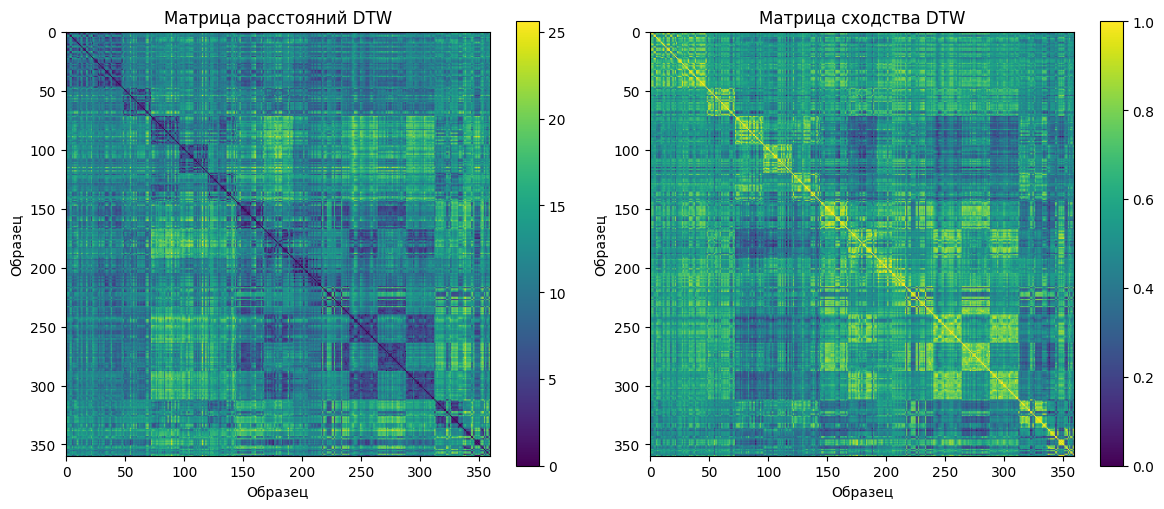

In [7]:
idx_sorted = np.argsort(Y_all[:,0])
dtw_dist_sorted = dtw_dist_all[:,idx_sorted][idx_sorted,:]
dtw_sim_sorted  = dtw_sim_all[:,idx_sorted][idx_sorted,:]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(dtw_dist_sorted, cmap='viridis')
axes[0].set_title("Матрица расстояний DTW")
axes[0].set_xlabel("Образец")
axes[0].set_ylabel("Образец")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(dtw_sim_sorted, cmap='viridis')
axes[1].set_title("Матрица сходства DTW")
axes[1].set_xlabel("Образец")
axes[1].set_ylabel("Образец")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


вижу частичную блочную структуру вдоль главной диагонали

#### 4: Классификация с SVC и k-NN на основе DTW

In [8]:
n_tr = Xtr.shape[0]

# разбиваем матрицы на нужные части
sim_trtr = dtw_sim_all[:n_tr, :n_tr]
sim_tetr = dtw_sim_all[n_tr:, :n_tr]
dist_trtr = dtw_dist_all[:n_tr, :n_tr]
dist_tetr = dtw_dist_all[n_tr:, :n_tr]

# SVC
t0 = time.time()
clf_svc = svm.SVC(kernel='precomputed', C=1)
clf_svc.fit(sim_trtr, Ytr.ravel())
t_train_svc = time.time() - t0

t0 = time.time()
y_pred_svc = clf_svc.predict(sim_tetr)
t_test_svc = time.time() - t0

acc_svc = accuracy_score(Yte.ravel(), y_pred_svc)
f1_svc  = f1_score(Yte.ravel(), y_pred_svc, average='macro')

print("SVC (DTW-ядро):")
print(f"  Время обучения:    {t_train_svc:.3f} сек.")
print(f"  Время тестирования: {t_test_svc:.3f} сек.")
print(f"  Точность (Accuracy): {acc_svc:.3f}")
print(f"  F1-мера (macro):     {f1_svc:.3f}")

# k-NN
t0 = time.time()
neigh = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
neigh.fit(dist_trtr, Ytr.ravel())
t_train_knn = time.time() - t0

t0 = time.time()
y_pred_knn = neigh.predict(dist_tetr)
t_test_knn = time.time() - t0

acc_knn = accuracy_score(Yte.ravel(), y_pred_knn)
f1_knn  = f1_score(Yte.ravel(), y_pred_knn, average='macro')

print("\nk-NN (k=3, DTW-расстояние):")
print(f"  Время обучения:    {t_train_knn:.3f} сек.")
print(f"  Время тестирования: {t_test_knn:.3f} сек.")
print(f"  Точность (Accuracy): {acc_knn:.3f}")
print(f"  F1-мера (macro):     {f1_knn:.3f}")


SVC (DTW-ядро):
  Время обучения:    0.003 сек.
  Время тестирования: 0.000 сек.
  Точность (Accuracy): 0.744
  F1-мера (macro):     0.739

k-NN (k=3, DTW-расстояние):
  Время обучения:    0.000 сек.
  Время тестирования: 0.005 сек.
  Точность (Accuracy): 0.833
  F1-мера (macro):     0.828


по метрикам победил k-NN

#### 5: Иерархическая кластеризация

In [10]:
distArray_dtw = ssd.squareform(dtw_dist_all)
Z_dtw = linkage(distArray_dtw, 'ward')
print("end")

end


6: Визуализация дендрограммы и выбор порога

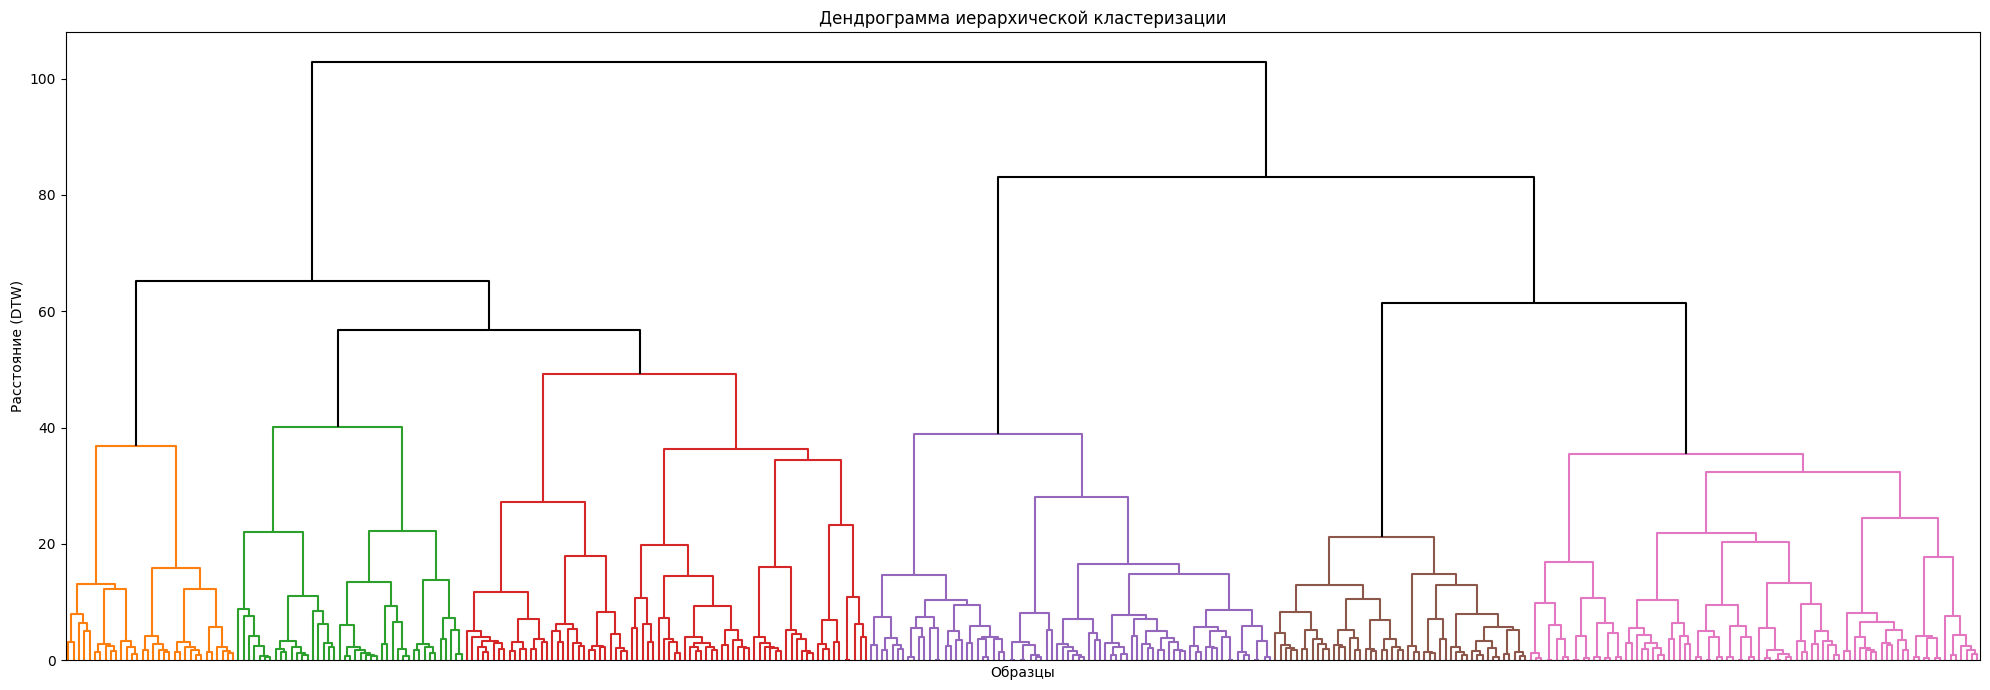

In [11]:
fig = plt.figure(figsize=(20, 7))
dn = dendrogram(Z_dtw, color_threshold=50, above_threshold_color='k',
                show_leaf_counts=False)
plt.xticks([])
plt.title("Дендрограмма иерархической кластеризации")
plt.xlabel("Образцы")
plt.ylabel("Расстояние (DTW)")
plt.tight_layout()
plt.show()


Дендрограмма показывает структуру из 7 устойчивых групп. это указывает на то, что 15 классов группируются в 7 более крупных суперклассов по траекторной схожести

#### 7: Снижение размерности с KernelPCA и визуализация

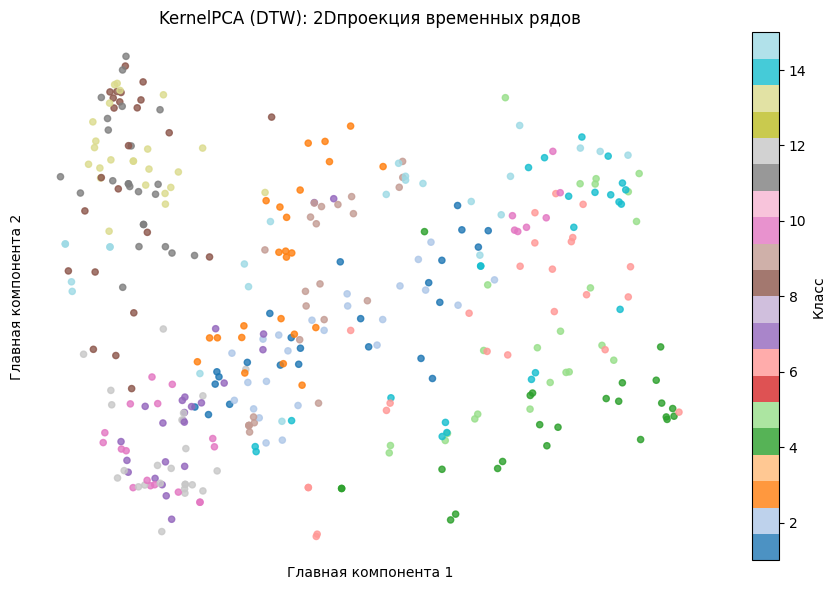

In [12]:
kpca_dtw = KernelPCA(n_components=2, kernel='precomputed')
emb_dtw = kpca_dtw.fit_transform(dtw_sim_all)

fig = plt.figure(figsize=(9, 6))
sc = plt.scatter(emb_dtw[:,0], emb_dtw[:,1], c=Y_all.ravel(),
                 s=20, cmap='tab20', alpha=0.8)
plt.colorbar(sc, label='Класс')
plt.title("KernelPCA (DTW): 2Dпроекция временных рядов")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.gca().spines[['right', 'left', 'top', 'bottom']].set_visible(False)
plt.xticks(())
plt.yticks(())
plt.tight_layout()
plt.show()


как будто бы четких разделенных групп не видно, 2D-проекция показывает одно большое облако точек с частичной структурой. Вижу относительно изолированные классы оранжевые, зеленые, голубые